![image.png](https://i.imgur.com/a3uAqnb.png)

# Exercise: Image Classification using CNN — NEU Steel Surface Defects 🏭

> **Your turn!** You just trained a CNN on CIFAR-10 (planes, cats, frogs...). Now let's apply the same skills to a **real industrial problem** at YASREF.

### The Problem
Inspection Engineers examine steel surfaces every day to spot defects. Can a CNN learn to do the same?

### The Dataset: NEU Surface Defect Database
- **Images**: 1,800 grayscale images of size **(200x200)** in **6 categories**, with 300 images per class.
- **Classes**: `Crazing (Cr)`, `Inclusion (In)`, `Patches (Pa)`, `Pitted Surface (PS)`, `Rolled-in scale (RS)`, `Scratches (Sc)`.
- **Shape**: `(batch_size, 1, 200, 200)` → 1 channel (grayscale).
- **Source**: [Kaggle - NEU Metal Surface Defects Data](https://www.kaggle.com/datasets/fantacher/neu-metal-surface-defects-data)


## 0️⃣ Download the Dataset

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("kaustubhdikshit/neu-surface-defect-database")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'neu-surface-defect-database' dataset.
Path to dataset files: /kaggle/input/neu-surface-defect-database


In [2]:
import os

# The dataset has a top-level folder "NEU Metal Surface Defects Data" inside the download path
DATA_DIR = os.path.join(path, "NEU-DET")

# Confirm the folder structure looks right
print("Contents of DATA_DIR:", os.listdir(DATA_DIR))
print("Train classes:", os.listdir(os.path.join(DATA_DIR, 'train', 'images')))


Contents of DATA_DIR: ['validation', 'train']
Train classes: ['inclusion', 'scratches', 'pitted_surface', 'patches', 'crazing', 'rolled-in_scale']


## 1️⃣ Dataset Class

In [3]:
import torch
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
import os

# Define transformations
# The images are grayscale → we convert them to 1-channel tensors and resize to keep things fast
transform = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.ToTensor(),                         # converts to tensor and scales to [0, 1]
])

# Load the datasets using ImageFolder (this is our "Dataset class")
# ImageFolder automatically reads class names from the folder names
# Note: this dataset only has train/ and validation/ — we'll use validation as our test set too
train_dataset = ImageFolder(root=os.path.join(DATA_DIR, 'train', 'images'),      transform=transform)
test_dataset   = ImageFolder(root=os.path.join(DATA_DIR, 'validation', 'images'), transform=transform)

# Create DataLoaders (same as in the tutorial)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader   = DataLoader(test_dataset,   batch_size=32, shuffle=False)

# Check dataset size and the classes that were detected
print(f"Training samples: {len(train_dataset)}, Validation samples: {len(test_dataset)}")
print(f"Classes detected: {train_dataset.classes}")

Training samples: 1440, Validation samples: 360
Classes detected: ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']


In [4]:
data_iter = iter(train_loader)
images, labels = next(data_iter)

print(images[0].shape)

torch.Size([3, 64, 64])


### Let's display some images

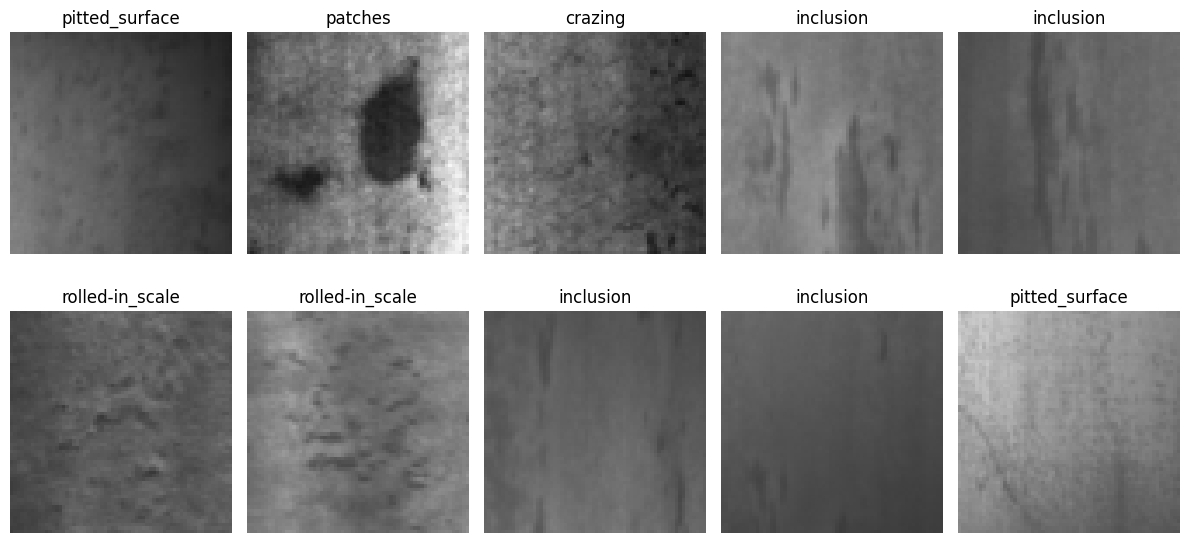

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Get a batch of training data
data_iter = iter(train_loader)
images, labels = next(data_iter)

# Class names come from the folders
classes = train_dataset.classes

# Show images
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    img = images[i].numpy().transpose(1, 2, 0)   # (3, H, W) → (H, W, 3) for matplotlib
    ax.imshow(img)                               # no cmap needed for RGB
    ax.set_title(classes[labels[i]])
    ax.axis('off')

plt.tight_layout()
plt.show()

In [6]:
print("Shape of one image tensor:", images[0].shape)  # Expected: (3, 64, 64)
print("Number of classes:", len(classes))


Shape of one image tensor: torch.Size([3, 64, 64])
Number of classes: 6


## 2️⃣ Model Class

In [7]:
import torch.nn as nn
import torch

# Define the CNN Model
class CNNModel(nn.Module):
    def __init__(self, num_classes=6):
        super(CNNModel, self).__init__()

        # Convolutional Layers
        self.conv1 = nn.Conv2d(in_channels=3,  out_channels=16, kernel_size=3, padding=1)   # ← in_channels=1 (grayscale)
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)

        # Activation
        self.relu = nn.ReLU()

        # Pooling Layer
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # Fully Connected Layers
        # Input is 64x64 → after 3 poolings → 8x8, with 64 channels → 64*8*8
        self.fc1 = nn.Linear(64 * 8 * 8, 128)
        self.fc2 = nn.Linear(128, num_classes)   # ← 6 output classes for NEU

    def forward(self, x):
        # Convolution + ReLU + Pooling
        x = self.pool(self.relu(self.conv1(x)))  # (Batch, 16, 32, 32)
        x = self.pool(self.relu(self.conv2(x)))  # (Batch, 32, 16, 16)
        x = self.pool(self.relu(self.conv3(x)))  # (Batch, 64,  8,  8)

        # Flatten
        x = x.view(x.size(0), -1)  # (Batch, 64*8*8)

        # Fully Connected Layers
        x = self.relu(self.fc1(x))
        x = self.fc2(x)  # Logits

        return x   # No softmax — CrossEntropyLoss applies it for us 👀


## 3️⃣ Training and Validation Loops

In [8]:
from tqdm import tqdm    # Shows progress bar

# 🔹 Training Loop
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()  # Set model to training mode
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in tqdm(dataloader):
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)            # Forward pass
        loss = criterion(outputs, labels)  # Compute loss

        optimizer.zero_grad()  # Reset gradients
        loss.backward()        # Backpropagation
        optimizer.step()       # Update weights

        total_loss += loss.item()

        # Track accuracy
        outputs = torch.softmax(outputs, dim=1)
        predictions = outputs.argmax(dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    avg_loss = total_loss / len(dataloader)
    accuracy = 100 * correct / total
    return avg_loss, accuracy

# 🔹 Validation Loop
def validate(model, dataloader, criterion, device):
    model.eval()  # Set model to evaluation mode
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():  # Disable gradient computation
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()

            outputs = torch.softmax(outputs, dim=1)
            predictions = outputs.argmax(dim=1)
            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    avg_loss = total_loss / len(dataloader)
    accuracy = 100 * correct / total
    return avg_loss, accuracy


## 4️⃣ Running Training

In [9]:
import torch.optim as optim

# Initialize the model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNNModel(num_classes=6).to(device)

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()                       # Multi-class classification (Input: Logits)
optimizer = optim.Adam(model.parameters(), lr=0.001)    # Adam optimizer
num_epochs = 10

# Lists to store metrics
train_losses = []
test_losses = []
train_accuracies = []
test_accuracies = []

# Training loop
for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc     = validate(model, test_loader, criterion, device)

    train_losses.append(train_loss)
    test_losses.append(val_loss)
    train_accuracies.append(train_acc)
    test_accuracies.append(val_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")


100%|██████████| 45/45 [00:11<00:00,  3.92it/s]


Epoch [1/10] Train Loss: 1.6621, Train Acc: 30.62% | Val Loss: 1.7169, Val Acc: 39.72%


100%|██████████| 45/45 [00:02<00:00, 15.53it/s]


Epoch [2/10] Train Loss: 1.2951, Train Acc: 55.28% | Val Loss: 1.5956, Val Acc: 40.83%


100%|██████████| 45/45 [00:02<00:00, 15.29it/s]


...

Epoch [8/10] Train Loss: 0.4300, Train Acc: 84.93% | Val Loss: 1.1221, Val Acc: 58.61%


100%|██████████| 45/45 [00:02<00:00, 15.44it/s]


Epoch [9/10] Train Loss: 0.3368, Train Acc: 89.44% | Val Loss: 1.3004, Val Acc: 58.61%


100%|██████████| 45/45 [00:03<00:00, 12.47it/s]


Epoch [10/10] Train Loss: 0.3028, Train Acc: 90.00% | Val Loss: 0.4181, Val Acc: 86.39%


### Plot loss and some predictions

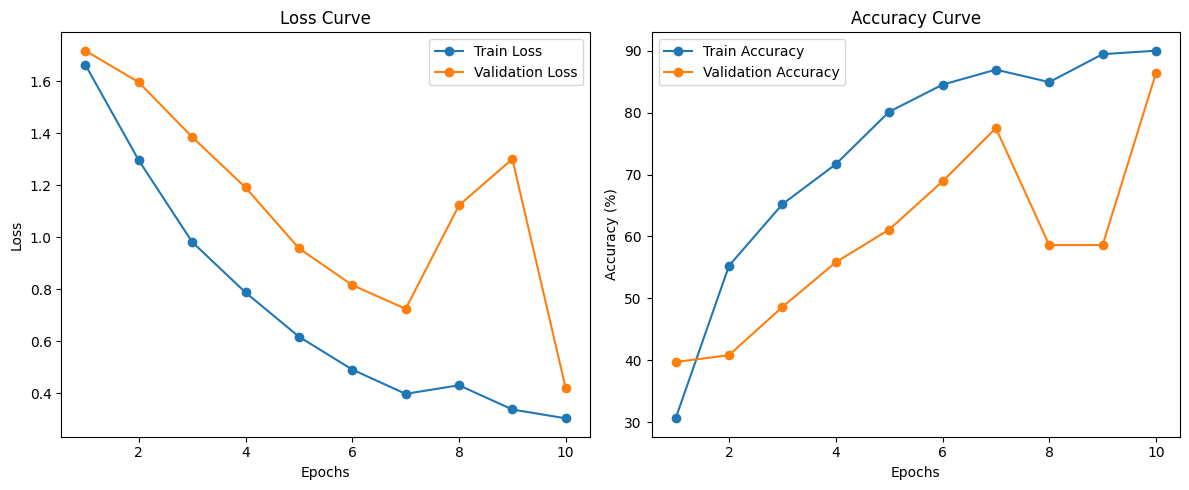

In [10]:
import matplotlib.pyplot as plt

# Plot loss curve
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1, num_epochs+1), train_losses, label="Train Loss", marker='o')
plt.plot(range(1, num_epochs+1), test_losses,   label="Validation Loss", marker='o')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()

# Plot accuracy curve
plt.subplot(1, 2, 2)
plt.plot(range(1, num_epochs+1), train_accuracies, label="Train Accuracy", marker='o')
plt.plot(range(1, num_epochs+1), test_accuracies,   label="Validation Accuracy", marker='o')
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy Curve")
plt.legend()

plt.tight_layout()
plt.show()


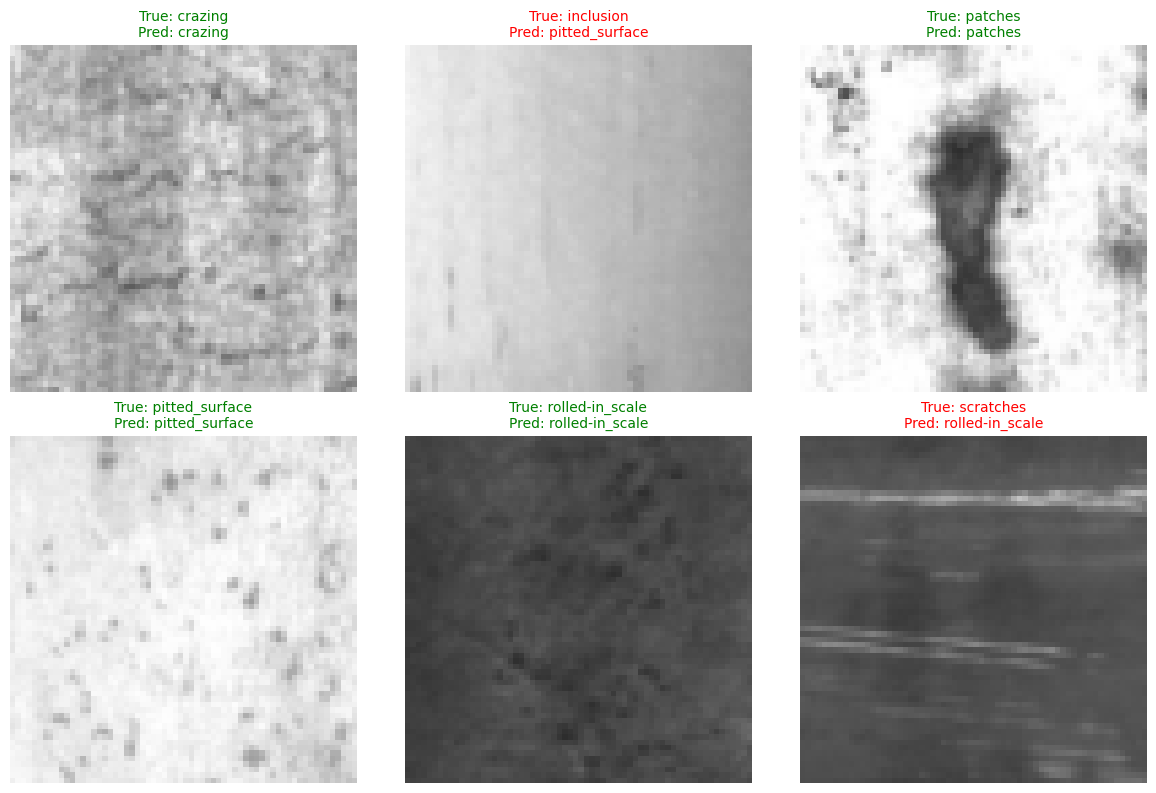

In [11]:
def show_predictions(model, dataloader, device):
    model.eval()
    classes = train_dataset.classes
    dataset = dataloader.dataset

    # Pick one random image per class
    import random
    samples_per_class = {}
    for img, label in dataset:
        if label not in samples_per_class:
            samples_per_class[label] = img
        if len(samples_per_class) == len(classes):
            break

    images = torch.stack([samples_per_class[i] for i in range(len(classes))]).to(device)
    labels = torch.tensor(list(range(len(classes)))).to(device)

    with torch.no_grad():
        outputs = model(images)
        predictions = outputs.argmax(dim=1)

    fig, axes = plt.subplots(2, 3, figsize=(12, 8))
    for i, ax in enumerate(axes.flat):
        img = images[i].cpu().numpy().transpose(1, 2, 0)
        ax.imshow(img)
        true_label = classes[labels[i]]
        pred_label = classes[predictions[i]]
        color = "green" if true_label == pred_label else "red"
        ax.set_title(f"True: {true_label}\nPred: {pred_label}", color=color, fontsize=10)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

show_predictions(model, test_loader, device)

### Contributed by: Yazan Alshoibi

![image.png](https://i.imgur.com/a3uAqnb.png)